A **Decision Tree** is a supervised machine learning algorithm used for both **classification** (predicting a categorical label, like Spam vs. Not Spam) and **regression** (predicting a continuous value, like house prices).

It works by continuously breaking down a dataset into smaller, more specific subsets based on yes/no or numerical test conditions, forming a flowchart-like tree structure.

---

## 1. Core Structure of a Decision Tree

```
               [ Root Node ]        <-- Top decision based on the best splitting feature
                /         \
          ( Condition )  ( Condition )
              /             \
      [ Decision Node ]   [ Leaf Node ] <-- Final predicted outcome
          /        \
   [ Leaf Node ] [ Leaf Node ]

```

* **Root Node:** Represents the entire dataset and the initial decision test.
* **Decision Nodes (Internal Nodes):** Intermediate splits that test a specific feature/attribute.
* **Branches:** The outcome of a test condition leading to the next node.
* **Leaf Nodes (Terminal Nodes):** The end points of the tree that contain the final class prediction or numerical output value.

---

## 2. How Decision Trees Split Data

The tree decides *where* and *how* to split data by evaluating which feature provides the clearest distinction between outcomes. It measures this using specific mathematical criteria:

* **Classification Trees:**
* **Gini Impurity:** Measures how often a randomly chosen element from the set would be incorrectly labeled. A Gini score of `0` means a perfectly pure/homogenous node.
* **Entropy & Information Gain:** Based on information theory, it measures the degree of randomness or disorder in the data. The algorithm selects the split that maximizes **Information Gain** (reduces entropy the most).


* **Regression Trees:**
* **Variance Reduction / Mean Squared Error (MSE):** Selects splits that minimize the variance or squared error within each resulting child node.



---

## 3. Concrete Example: Deciding to Play Tennis

If a model predicts whether to play tennis based on weather:

1. **Root Node:** Tests `Outlook` (Sunny, Overcast, Rain).
* If **Overcast** $\rightarrow$ Predict: **Play (Leaf Node)**
* If **Sunny** $\rightarrow$ Branch to Decision Node: Test `Humidity`.
* High Humidity $\rightarrow$ Predict: **Don't Play**
* Normal Humidity $\rightarrow$ Predict: **Play**


* If **Rain** $\rightarrow$ Branch to Decision Node: Test `Wind`.
* Strong Wind $\rightarrow$ Predict: **Don't Play**
* Weak Wind $\rightarrow$ Predict: **Play**





---

## 4. Key Advantages & Disadvantages

| Advantages | Disadvantages |
| --- | --- |
| **Easy to interpret:** Visually intuitive and acts like human reasoning. | **Overfitting:** Unrestricted trees grow deep and memorize noise in training data. |
| **Minimal data prep:** Handles both numerical and categorical data without requiring scaling. | **Instability:** Small changes in input data can yield a completely different tree structure. |
| **Non-linear relationships:** Captures complex patterns without assuming linear boundaries. | **Bias towards dominant classes:** Can perform poorly on highly imbalanced datasets. |

---

## 5. Preventing Overfitting (Pruning)

To stop a tree from over-complicating itself:

1. **Pre-pruning (Early Stopping):** Limit maximum tree depth (`max_depth`), require a minimum number of samples per leaf (`min_samples_leaf`), or set a maximum leaf limit.
2. **Post-pruning:** Let the tree fully grow, then remove branches that provide minimal predictive value (e.g., Cost-Complexity Pruning).

To overcome single-tree instability and overfitting in practice, ensemble methods like **Random Forests** or **Gradient Boosted Trees (XGBoost)** combine multiple decision trees together for higher accuracy.

In [1]:
# Cell 1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

### Explanation

This code imports the libraries needed for plotting, numeric work, dataset loading, and model evaluation.



In [2]:
# Cell 2
# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

# Display the first few rows of the feature matrix
print("Dataset Head:")
print(X.head())

# Feature and target target names
print("\nTarget classes:", iris.target_names)

Dataset Head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target classes: ['setosa' 'versicolor' 'virginica']


### Explanation

This block loads the Iris dataset, converts it into a pandas DataFrame, and shows the first few records so the feature layout is visible.



In [3]:
# Cell 3
# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size:  30 samples


### Explanation

This step divides the dataset into training and testing subsets, preserving the class balance for a fair evaluation.



In [4]:
# Cell 4
# Initialize the Decision Tree Classifier
# We set max_depth to pre-prune the tree and prevent overfitting
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)

# Fit the model on training data
clf.fit(X_train, y_train)

print("Decision Tree model successfully trained!")

Decision Tree model successfully trained!


### Explanation

A decision tree classifier is created and trained on the training data. The tree is limited to a maximum depth to reduce overfitting and keep the model interpretable.



In [5]:
# Cell 5
# Predict outcomes on test data
y_pred = clf.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


### Explanation

The trained model predicts the species for the test set, and the accuracy plus classification metrics are printed to assess performance.



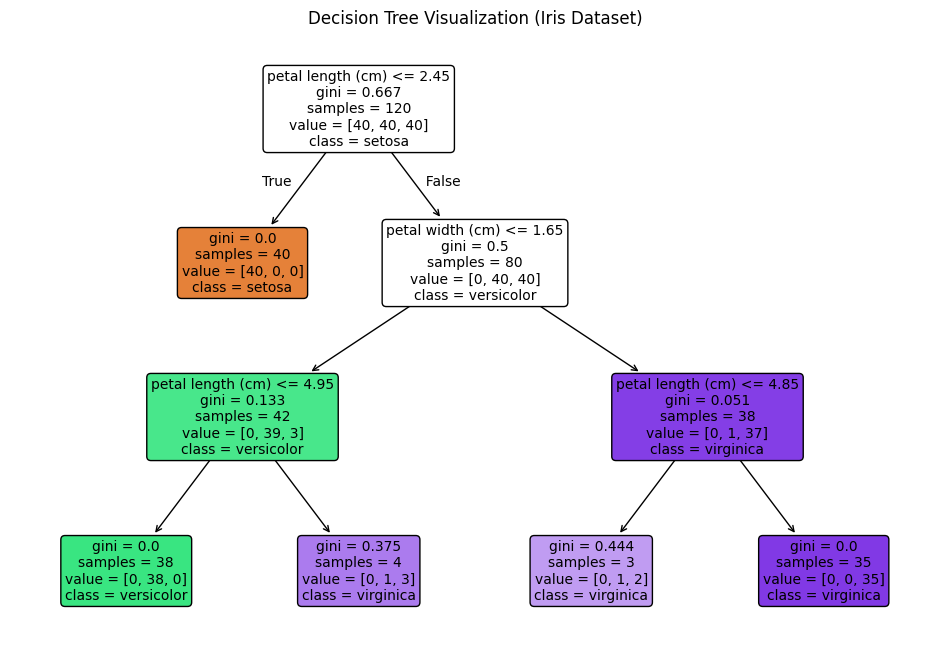

In [6]:
# Cell 6
# Plot the learned decision tree structure
plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Visualization (Iris Dataset)")
plt.show()

### Explanation

This block visualizes the trained decision tree graph to show how splits are made based on feature thresholds.



In [7]:
# Cell 7
# Predict species for a new, unseen sample
# [sepal length, sepal width, petal length, petal width]
new_flower_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_class_id = clf.predict(new_flower_sample)[0]
predicted_class_name = iris.target_names[predicted_class_id]

print(f"Input Features: {new_flower_sample[0]}")
print(f"Predicted Iris Species: {predicted_class_name}")

Input Features: [5.1 3.5 1.4 0.2]
Predicted Iris Species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Explanation

This final example uses a new flower sample to demonstrate how the model predicts the class for unseen data.

